In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [85]:
df=pd.read_csv(r'C:\Users\fathi\OneDrive\Desktop\5thsem_OJT\project_diabetes\data\processed\risvana_p1w2_features.csv')

In [86]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age band,bmi category,glucose category,insulin_glucose_ratio,pregnancies_age_rate,days_since_checkup,smoker_activity
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,over 55,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,35-55,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,35-55,over weight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,over 55,over weight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,over 55,normal,prediabetic,0.943925,0.000000,336,Low/NO


In [87]:

feature_cols = [
    'age',
    'pregnancies',
    'glucose',
    'blood_pressure',
    'skin_thickness',
    'insulin',
    'bmi',
    'diabetes_pedigree',
    'bmi category',
    'glucose category'
]

In [88]:
x = df[feature_cols].copy()
y = df["outcome"]


In [89]:
                                                               
x=pd.get_dummies(x,drop_first=True)

In [90]:
x_train,x_test,y_train,y_test= train_test_split(
x,y,test_size=0.2,random_state=42,stratify=y)

In [91]:
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [92]:
logreg = LogisticRegression(max_iter=1000).fit(x_train_scaled, y_train)

dec_tree = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)

knn_best = KNeighborsClassifier(n_neighbors=25).fit(x_train_scaled, y_train)

In [93]:
print('LogisticRegression',accuracy_score(y_test,logreg.predict(x_test_scaled)))
print('DecisionTreeClassifier',accuracy_score(y_test,dec_tree.predict(x_test)))
print('kneighborsclassifier',accuracy_score(y_test,knn_best.predict(x_test_scaled)))

LogisticRegression 0.7526315789473684
DecisionTreeClassifier 0.7210526315789474
kneighborsclassifier 0.7473684210526316


In [94]:
print('test set:',len(y_test),'patients |',int(np.sum(y_test)),'of them diabetic')

test set: 190 patients | 55 of them diabetic


In [95]:
models=[('logisticregression',logreg,x_test_scaled),
        ('DecisionTreeClassifier(d=3)',dec_tree,x_test),
        ('knn(k=25)',knn_best,x_test_scaled)]

In [96]:
rows=[]
for name,m,xt in models:
    cm=confusion_matrix(y_test,m.predict(xt))
    tn,fp,fn,tp=cm.ravel()
    rows.append({"model":name,"correct_negatives":int(tn),"false_alarams":int(fp),
              "missed_patients":int(fn),"found_patients":int(tp),
              "accuracy": round(accuracy_score(y_test,m.predict(xt)),4)})
matrix=pd.DataFrame(rows)
matrix


,model,correct_negatives,false_alarams,missed_patients,found_patients,accuracy
0,logisticregression,127,8,39,16,0.7526
1,DecisionTreeClassifier(d=3),121,14,39,16,0.7211
2,knn(k=25),132,3,45,10,0.7474


                        logistic regression
* **127 (TN):** 127 people were correctly identified as not having diabetes.
* **8 (FP):** 8 people were incorrectly identified as having diabetes.
* **39 (FN):** 39 people who actually had diabetes were missed by the model.
* **16 (TP):** 16 people who had diabetes were correctly identified by the model.


* **Logistic Regression:** The main error is **missed patients (FN = 39)**.
* **Decision Tree:** The main error is **missed patients (FN = 39)**, along with 14 false alarms.
* **KNN:** The main error is **missed patients (FN = 45)**, which is the highest among the three models.



score the model that never says yes

In [97]:
from sklearn.dummy import DummyClassifier


In [98]:
dummy=DummyClassifier(strategy='most_frequent')
dummy.fit(x_train,y_train)
y_pred=dummy.predict(x_test)
confusion_matrix(y_test,y_pred)

array([[135,   0],
       [ 55,   0]])

In [99]:
print('dummyclassifier',accuracy_score(y_test,y_pred))

dummyclassifier 0.7105263157894737


In [100]:
y_test.value_counts(normalize=True)

outcome
0    0.710526
1    0.289474
Name: proportion, dtype: float64

# precision and recall


Recall → How many actual positives did I find?
Formula: TP / (TP + FN)

In [101]:
cm=confusion_matrix(y_test,logreg.predict(x_test_scaled))
tn,fp,fn,tp=cm.ravel()
print("recall : tp/tp+fn", tp/(tp+fn))

recall : tp/tp+fn 0.2909090909090909


In [102]:
from sklearn.metrics import recall_score
recall_score(y_test,logreg.predict(x_test_scaled))

0.2909090909090909

In [103]:
recall_score(y_test,logreg.predict(x_test_scaled))
print("DecisionTreeClassifier  Recall =",recall_score(y_test,dec_tree.predict(x_test)))
print("KNeighborsClassifier  Recall =",recall_score(y_test,knn_best.predict(x_test_scaled)))
print("LogisticRegression  recall=",recall_score(y_test,logreg.predict(x_test_scaled)))

DecisionTreeClassifier  Recall = 0.2909090909090909
KNeighborsClassifier  Recall = 0.18181818181818182
LogisticRegression  recall= 0.2909090909090909


# precision

Precision = How correct are my positive predictions?
Formula: TP / (TP + FP)

In [104]:
confusion_matrix(y_test,logreg.predict(x_test_scaled))
tn,fp,fn,tp=cm.ravel()
print("precision : tp/tp+f", tp/(tp+fp))

precision : tp/tp+f 0.6666666666666666


In [105]:
from sklearn.metrics import precision_score
precision_score(y_test,logreg.predict(x_test_scaled))

0.6666666666666666

In [106]:
precision_score(y_test,logreg.predict(x_test_scaled))
print("DecisionTreeClassifier  precision =",precision_score(y_test,dec_tree.predict(x_test)))
print("KNeighborsClassifier  precision =",precision_score(y_test,knn_best.predict(x_test_scaled)))
print("LogisticRegression  precision=",precision_score(y_test,logreg.predict(x_test_scaled)))

DecisionTreeClassifier  precision = 0.5333333333333333
KNeighborsClassifier  precision = 0.7692307692307693
LogisticRegression  precision= 0.6666666666666666


build the three metric table

In [107]:
rows = []

for name, m, Xt in models:
    pred = m.predict(Xt)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred), 4),
        "recall": round(recall_score(y_test, pred), 4),
        "found": int(tp),
        "missed": int(fn),
        "false_alarms": int(fp)
    })

result = pd.DataFrame(rows)

sort by precision

In [108]:
print(result.sort_values(by="precision", ascending=False).to_string())

                         model  accuracy  precision  recall  found  missed  false_alarms
2                    knn(k=25)    0.7474     0.7692  0.1818     10      45             3
0           logisticregression    0.7526     0.6667  0.2909     16      39             8
1  DecisionTreeClassifier(d=3)    0.7211     0.5333  0.2909     16      39            14


sort by recall

In [109]:
print(result.sort_values(by="recall", ascending=False).to_string())

                         model  accuracy  precision  recall  found  missed  false_alarms
0           logisticregression    0.7526     0.6667  0.2909     16      39             8
1  DecisionTreeClassifier(d=3)    0.7211     0.5333  0.2909     16      39            14
2                    knn(k=25)    0.7474     0.7692  0.1818     10      45             3


In [110]:
probs = logreg.predict_proba(x_test_scaled)[:, 1]
preds = logreg.predict(x_test_scaled)

pd.DataFrame({"probability": probs[: 10].round(3),
              "prediction" : preds[:10],
              "actuall"    : np.asarray(y_test)[:10]})

,probability,prediction,actuall
0,0.289,0,0
1,0.032,0,0
2,0.182,0,0
3,0.182,0,0
4,0.177,0,1
5,0.161,0,0
6,0.419,0,0
7,0.473,0,1
8,0.286,0,0
9,0.121,0,0


In [111]:
sweep = []

for t in [0.5,0.45,0.4,0.35,0.3,0.25,0.2,0.15]:
    pred_t = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm.ravel()

    sweep.append({
        "threshold": t,
        "accuracy": round(accuracy_score(y_test, pred_t), 4),
        "precision": round(precision_score(y_test, pred_t), 4),
        "recall": round(recall_score(y_test, pred_t), 4),
        "found": int(tp),
        "missed": int(fn),
        "false_alarms": int(fp)
    })

sweep=pd.DataFrame(sweep)
sweep

,threshold,accuracy,precision,recall,found,missed,false_alarms
0,0.50,0.7526,0.6667,0.2909,16,39,8
1,0.45,0.7316,0.5556,0.3636,20,35,16
2,0.40,0.7105,0.5000,0.4364,24,31,24
3,0.35,0.7158,0.5082,0.5636,31,24,30
4,0.30,0.6947,0.4789,0.6182,34,21,37
5,0.25,0.6158,0.4043,0.6909,38,17,56
6,0.20,0.5789,0.3874,0.7818,43,12,68
7,0.15,0.5316,0.3692,0.8727,48,7,82


# F1

F1 Score: A measure of a model’s precision and recall balance

Formula:F1 = 2 × (Precision × Recall) / (Precision + Recall)

In [112]:
from sklearn.metrics import f1_score

In [113]:
print(f"f1_score_logistic regression={f1_score(y_test,logreg.predict(x_test_scaled)):.4f}")
print(f"f1_score_decisiontree={f1_score(y_test,logreg.predict(x_test_scaled)):.4f}")
print(f"f1_score_knn={f1_score(y_test,logreg.predict(x_test_scaled)):.4f}")

f1_score_logistic regression=0.4051
f1_score_decisiontree=0.4051
f1_score_knn=0.4051


In [114]:
from sklearn.metrics import f1_score, classification_report
f1_score(y_test,pred)
print(classification_report(y_test,pred,digits=4))

              precision    recall  f1-score   support

           0     0.7458    0.9778    0.8462       135
           1     0.7692    0.1818    0.2941        55

    accuracy                         0.7474       190
   macro avg     0.7575    0.5798    0.5701       190
weighted avg     0.7526    0.7474    0.6864       190



In [115]:
result["f1"]=[f1_score(y_test,m.predict(Xt))
              for model,m,Xt in models]
print(result[["model", "accuracy", "precision", "recall","f1"]].sort_values(by="f1", ascending=False).round(4)
)

                         model  accuracy  precision  recall      f1
0           logisticregression    0.7526     0.6667  0.2909  0.4051
1  DecisionTreeClassifier(d=3)    0.7211     0.5333  0.2909  0.3765
2                    knn(k=25)    0.7474     0.7692  0.1818  0.2941


In [116]:
result["f1"]=[f1_score(y_test,m.predict(Xt))
              for model,m,Xt in models]
print(
    result[["model", "accuracy", "precision", "recall", "f1"]]
    .sort_values(by="f1", ascending=False)
    .round(4)
)
print("Dummy Accuracy:", accuracy_score(y_test, y_pred))
print("Dummy Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Dummy Recall:", recall_score(y_test, y_pred, zero_division=0))
print("Dummy F1:", f1_score(y_test, y_pred, zero_division=0))

                         model  accuracy  precision  recall      f1
0           logisticregression    0.7526     0.6667  0.2909  0.4051
1  DecisionTreeClassifier(d=3)    0.7211     0.5333  0.2909  0.3765
2                    knn(k=25)    0.7474     0.7692  0.1818  0.2941
Dummy Accuracy: 0.7105263157894737
Dummy Precision: 0.0
Dummy Recall: 0.0
Dummy F1: 0.0


find the threshold that maximises f1

In [117]:
sweep['f1'] = [f1_score(y_test, (probs >= t).astype(int), zero_division=0)
             for t in sweep['threshold']]
print(sweep[['threshold', 'accuracy', 'precision', 'recall', 'f1','found','missed']].sort_values("f1", ascending=False).to_string(index=False))



 threshold  accuracy  precision  recall       f1  found  missed
      0.30    0.6947     0.4789  0.6182 0.539683     34      21
      0.35    0.7158     0.5082  0.5636 0.534483     31      24
      0.15    0.5316     0.3692  0.8727 0.518919     48       7
      0.20    0.5789     0.3874  0.7818 0.518072     43      12
      0.25    0.6158     0.4043  0.6909 0.510067     38      17
      0.40    0.7105     0.5000  0.4364 0.466019     24      31
      0.45    0.7316     0.5556  0.3636 0.439560     20      35
      0.50    0.7526     0.6667  0.2909 0.405063     16      39


In [118]:
best = sweep.loc[sweep['f1'].idxmax()]

compare the model

In [119]:
tuned_pred = (probs >= 0.30).astype(int)
def score_row(label, pred):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model": label,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, pred, zero_division=0), 4),
        "found": int(tp),
        "missed": int(fn),
        "false_alarms": int(fp)}
pd.DataFrame([
    score_row("Logistic Regression (threshold 0.50)", preds),
    score_row("Logistic Regression (threshold 0.30)", tuned_pred)
])

,model,accuracy,precision,recall,f1,found,missed,false_alarms
0,Logistic Regression (threshold 0.50),0.7526,0.6667,0.2909,0.4051,16,39,8
1,Logistic Regression (threshold 0.30),0.6947,0.4789,0.6182,0.5397,34,21,37


# the  descion in one descion 

In [120]:
#We will judge this model on how many patients with diabetes it finds, because for this clinic sending a
# diabetic patient home untested is a worse outcome than calling a healthy patient back for a test they did not need

# ROC CURVE 

In [121]:
#ROC Curve: A graph used to measure the performance of a classification model

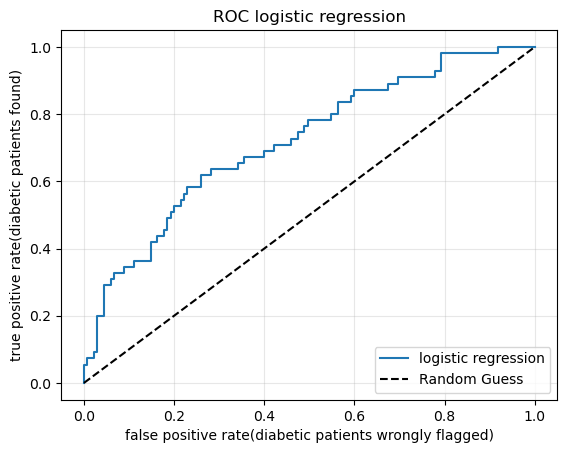

In [122]:
from sklearn.metrics import  roc_curve,roc_auc_score
import matplotlib.pyplot as plt

probs= logreg.predict_proba(x_test_scaled)[:,1]
fpr,tpr, thresholds = roc_curve(y_test,probs)

plt.plot(fpr,tpr,label="logistic regression")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("false positive rate(diabetic patients wrongly flagged)")
plt.ylabel("true positive rate(diabetic patients found)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.title("ROC logistic regression")
plt.show()

In [ ]:
i_50 = int(np.argmin(np.abs(thresholds - 0.50)))
i_30 = int(np.argmin(np.abs(thresholds - 0.30)))

print(f"Threshold 0.50 -> FPR {fpr[i_50]:.3f}, TPR (Recall) {tpr[i_50]:.3f}")
print(f"Threshold 0.30 -> FPR {fpr[i_30]:.3f}, TPR (Recall) {tpr[i_30]:.3f}")

plt.Figure(figsize=(6,5,4))
plt.plot([0,1],[0,1], )

threshold 0.50 -> fpr 0.022  tpr (recall) 0.091
threshold 0.30 -> fpr 0.059  tpr (recall) 0.309


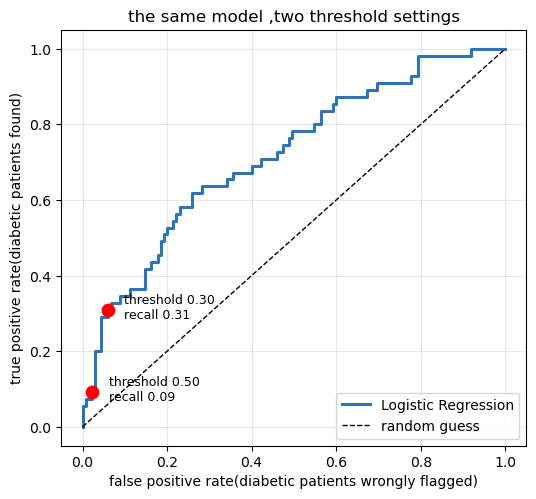

In [143]:
i_50 = int(np.argmin(np.abs(thresholds - 0.50)))
i_30 = int(np.argmin(np.abs(thresholds - 0.30)))

print(f"threshold 0.50 -> fpr {fpr[i_50]:.3f}  tpr (recall) {tpr[i_50]:.3f}")
print(f"threshold 0.30 -> fpr {fpr[i_30]:.3f}  tpr (recall) {tpr[i_30]:.3f}")

plt.figure(figsize=(6, 5.4))
plt.plot(fpr, tpr,lw=2.2, color="#2E75B7",label="Logistic Regression")
plt.plot([0, 1], [0, 1],"k--",lw=1, label="random guess")
plt.scatter(fpr[[i_50, i_30]],tpr[[i_50, i_30]],s=80,zorder=5,color="red")

plt.annotate(f"threshold 0.50\nrecall {tpr[i_50]:.2f}",(fpr[i_50],tpr[i_50]),
             textcoords="offset points",xytext=(12,-6),fontsize=9)
plt.annotate(f"threshold 0.30\nrecall {tpr[i_30]:.2f}",(fpr[i_30],tpr[i_30]),
             textcoords="offset points",xytext=(12,-6),fontsize=9)
plt.xlabel("false positive rate(diabetic patients wrongly flagged)")
plt.ylabel("true positive rate(diabetic patients found)")
plt.title("the same model ,two threshold settings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

plot all three curves together

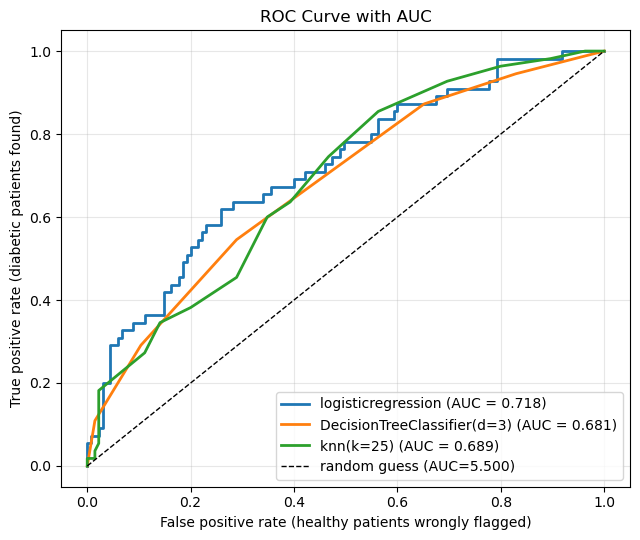

In [144]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6.5,5.5))

for name, m, xt in models:
    p = m.predict_proba(xt)[:,1]
    f, t, thresholds = roc_curve(y_test, p)
   
    plt.plot(f, t,lw=2,label=f"{name} (AUC = {roc_auc_score(y_test,p):.3f})")
plt.plot([0,1],[0,1], 'k--', lw=1, label='random guess (AUC=5.500)')
plt.xlabel("False positive rate (healthy patients wrongly flagged)")
plt.ylabel("True positive rate (diabetic patients found)")
plt.title("ROC Curve with AUC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Learn what AUC measures

In [147]:
# 0.5 means random guessing, while AUC 
# 1.0 means perfect separation between the two classes.